### PS-S06E04: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 4: Predicting Irrigation Need**](https://www.kaggle.com/competitions/playground-series-s6e4), a competition focused on predicting the irrigation needs of crops. The goal is to classify the required irrigation level into three categories: **Low (0), Medium (1), or High (2)**, based on environmental features including soil moisture, temperature, humidity, and crop variety.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it handles categorical features natively and robustly.

In this notebook we:
- Apply lightweight, physics-based feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** using **Stratified 5-Fold Cross-Validation**.
- Optimize for **Balanced Accuracy**, the primary evaluation metric for this competition.
- Collect **Out-of-Fold (OOF) probabilities** and test-set predictions for downstream ensembling.

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e04_feature_engineering import FeatureFactory
from ps_s06e04_model_visualizer import ModelVisualizer
from ps_s06e04_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# Target label column for S06E03
TARGET = 'Irrigation_Need'

# GPU usage (set True only if your environment supports CatBoost GPU)
USE_GPU = False

# Optional: Recursive Feature Elimination
PERFORM_RFE = True

# Optional: Optuna tuning
PERFORM_OPTUNA_TUNING = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy    4.920         32.580           1.010   
1   1      Clay    7.080         56.610           0.440   
2   2      Clay    5.690         27.710           0.810   
3   3     Sandy    5.650         13.320           1.330   
4   4      Clay    7.960         59.140           0.380   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    3.050         15.010    50.610      725.990   
1                    2.000         22.920    67.860      985.660   
2                    2.830         26.970    92.220    2,201.700   
3                    0.870         13.320    61.570    1,357.330   
4                    0.960         20.220    91.110    1,538.200   

   Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0           5.900          16.790  Sugarcane            Sowing    Zaid   
1           6.980           3.390      Wheat        Vegetative  Kharif

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt    6.360         26.190           0.590   
1  630001      Clay    5.870          9.880           1.180   
2  630002     Sandy    6.220         26.550           0.960   
3  630003      Clay    7.680         53.580           0.830   
4  630004     Loamy    5.230         59.020           0.540   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    2.810         17.830    30.240    1,533.380   
1                    3.260         21.180    78.070      576.050   
2                    0.850         26.870    60.350      545.300   
3                    0.550         41.740    36.050    1,211.030   
4                    2.110         41.080    52.470    1,321.910   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0           5.400           3.000     Maize            Sowing    Rabi   
1           7.220          15.880    Cotton         

## Feature Engineering Strategy

We apply a set of feature engineering steps designed to capture the relationship between soil conditions and atmospheric demand:

- `encoding`: Standardizes numeric features.
- `ratios`: Calculates features like the **Vapor Pressure Deficit (VPD)**, which represents the atmospheric "pull" on soil moisture.
- `interactions`: Creates terms between multiple features, such as a feature created based on `Soil_Type` and `Soil_Moisture` to account for varying water-holding capacities.
- `binning`: Groups continuous variables like `Temperature_C` into lifecycle stages.

**Categorical Handling**: We pass categorical fields like `Soil_Type`, `Crop_Type`, and `Region` directly to CatBoost. This allows the model to learn complex non-linear splits without the need for manual one-hot encoding.

In [5]:
# Define which feature engineering strategies to use
fe_strategies = [
    'encoding',
    'ratios',
    'interactions',
    'binning',
    'magic_formula'
]

In [6]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = training_df[TARGET].map(target_mapping).astype(int)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
print(f'Target sample: {y.head()}')
display(X.head())

Performing initial feature engineering.
Feature Count: 63
CatBoost categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Target sample: 0    0
1    0
2    0
3    1
4    0
Name: Irrigation_Need, dtype: int64


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,SVP,VPD,Water_Balance_Index,moisture_sq,wind_sq,temp_sq,rainfall_log,prev_irrig_log,field_area_log,moisture_rank,Soil_Moisture_Interaction,water_balance,temp_humidity_ratio,evaporation,water_deficit,soil_health,moisture_per_area,irrigation_efficiency,ET_proxy,heat_stress,drying_force,holding_cap,soil_quality,moisture_rainfall,temp_x_humidity,sun_temp,moist_x_wind,moist_x_temp,wind_x_temp,magic_soil_dry,magic_rain_low,magic_temp_hot,magic_wind_high,magic_harvest,magic_sowing,magic_mulch_yes,magic_high_score,magic_low_score,magic_score,magic_dist_to_boundary,margin_soil_25,margin_rain_300,margin_temp_30,margin_wind_10
0,Loamy,4.920,32.580,1.010,3.050,15.010,50.610,725.990,5.900,16.790,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820,No,112.160,East,1.707,0.843,722.988,"1,061.456",281.904,225.300,6.589,4.729,0.599,"256,923.500",65.160,838.150,0.297,43.739,-794.411,32.906,39.732,136.779,28.810,88.559,4.883,32.906,0.331,"23,652.754",759.656,88.559,547.018,489.026,252.018,0,0,0,1,0,1,0,1,2,-1,1,7.580,425.990,-14.990,6.790
1,Clay,7.080,56.610,0.440,2.000,22.920,67.860,985.660,6.980,3.390,Wheat,Vegetative,Kharif,Rainfed,River,5.270,Yes,47.160,South,2.797,0.899,981.076,"3,204.692",11.492,525.326,6.894,3.875,1.836,"533,981.500",226.440,"1,032.820",0.338,51.418,-981.402,24.908,10.742,8.949,7.876,159.982,1.128,24.908,0.220,"55,798.213","1,555.351",159.982,191.908,"1,297.501",77.699,0,0,0,0,0,0,1,0,1,-1,1,31.610,685.660,-7.080,-6.610
2,Clay,5.690,27.710,0.810,2.830,26.970,92.220,"2,201.700",6.050,3.850,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240,Yes,110.380,North,3.560,0.277,"2,196.306",767.844,14.823,727.381,7.697,4.713,2.224,"206,301.500",110.840,"2,312.080",0.292,12.695,"-2,299.385",22.445,3.363,13.396,6.739,163.168,1.114,22.445,0.286,"61,009.107","2,487.173",163.168,106.684,747.339,103.834,0,0,0,0,0,0,1,0,1,-1,1,2.710,"1,901.700",-3.030,-6.150
3,Sandy,5.650,13.320,1.330,0.870,13.320,61.570,"1,357.330",9.120,2.310,Wheat,Flowering,Kharif,Canal,River,8.320,Yes,53.850,South,1.530,0.588,"1,354.666",177.422,5.336,177.422,7.214,4.005,2.232,"57,158.000",13.320,"1,411.180",0.216,46.684,"-1,364.496",17.716,1.601,6.472,4.485,121.478,0.492,17.716,1.529,"18,079.636",820.112,121.478,30.769,177.422,30.769,1,0,0,0,0,0,1,2,1,1,1,-11.680,"1,057.330",-16.680,-7.690
4,Clay,7.960,59.140,0.380,0.960,20.220,91.110,"1,538.200",6.950,13.940,Wheat,Sowing,Rabi,Canal,River,7.370,No,93.190,South,2.371,0.211,"1,534.156","3,497.540",194.324,408.848,7.339,4.545,2.125,"561,447.500",236.560,"1,631.390",0.222,12.493,"-1,618.897",22.473,8.024,12.644,21.268,140.529,3.060,22.473,0.396,"90,969.148","1,842.244",140.529,824.412,"1,195.811",281.867,0,0,0,1,0,1,0,1,2,-1,1,34.140,"1,238.200",-9.780,3.940


In [7]:
# Categorical columns for this competition (integer-coded)
cat_cols = feature_engineer.get_cat_features(X)

cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as either int codes or strings. We keep strings here.
for c in cat_cols:
    # Convert all identified categorical columns to string
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

Categorical Features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


### Recursive Feature Elimination (RFE)

Optionally run **RFECV** to remove features that do not contribute to ROC AUC.

- This is relatively expensive for boosting models.
- In practice, feature selection often helps less than careful regularization and early stopping.
- Keep this off unless you are explicitly experimenting.


In [8]:
n_jobs = 1 if USE_GPU else -1

optimal_cols = X.columns

if PERFORM_RFE:
    print('Running Recursive Feature Elimination (RFECV)...')

    FS_RANDOM_SEED = seed
    FS_STEPS = 20  # higher = slower, potentially more stable (try 5/10/20/30)
    FS_EVAL_SPLIT = 0.2  # simple holdout inside selection
    
    y_fs = y.astype(np.int8)

    # Recreate features using your FeatureFactory (same as training)
    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_fs = fe_fs.fit_transform(training_df)
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Train/eval split for feature selection (stratified)
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_fs, y_fs))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y_fs.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y_fs.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    # Base model for selection.
    # You can swap in your tuned params once you have them; keep it modest for speed.
    fs_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='Accuracy',
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        feature_border_type='UniformAndQuantiles',
        border_count=254,
        random_seed=seed,
        auto_class_weights='Balanced', # Vital for Balanced Accuracy
        task_type='GPU' if USE_GPU else 'CPU',
        verbose=200,
        early_stopping_rounds=100,
        allow_writing_files=False,
    )

    # Select features
    # - RecursiveByShapValues: generally strong, slower
    # - RecursiveByLossFunctionChange: faster, often good enough
    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),  # select from all features
        num_features_to_select=int(X_tr_fs.shape[1] * 0.60),  # keep 85% (tune: 0.6–0.9)
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level="Verbose",
        plot=False
    )
    
    print("\nEliminated Features:", fs_result['eliminated_features_names'])
    print("Selected Features count:", len(fs_result['selected_features_names']))
    
    # To see the loss curve data that the plot would have shown:
    loss_graph = fs_result['loss_graph']
    print("Loss values at each step:", loss_graph['loss_values'])

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]

    print(f"\nSelected {len(optimal_cols)} / {X_fs.shape[1]} features.")

else:
    optimal_cols = [
        'Soil_Type',
        'Soil_pH',
        'Soil_Moisture',
        'Organic_Carbon',
        'Electrical_Conductivity',
        'Temperature_C',
        'Humidity',
        'Rainfall_mm',
        'Sunlight_Hours',
        'Wind_Speed_kmh',
        'Crop_Type',
        'Crop_Growth_Stage',
        'Irrigation_Type',
        'Water_Source',
        'Mulching_Used',
        'Previous_Irrigation_mm',
        'SVP',
        'VPD',
        'Water_Balance_Index',
        'moisture_sq',
        'wind_sq',
        'temp_sq',
        'rainfall_log',
        'prev_irrig_log',
        'moisture_rank',
        'water_balance',
        'water_deficit',
        'soil_quality',
        'moisture_rainfall',
        'magic_soil_dry'
    ]
    
    print("Feature selection skipped.")

print("Selected columns:")
print(optimal_cols[:30])


Running Recursive Feature Elimination (RFECV)...
Step #1 out of 20
0:	learn: 0.9612013	test: 0.9600290	best: 0.9600290 (0)	total: 763ms	remaining: 12m 42s
200:	learn: 0.9677825	test: 0.9668660	best: 0.9668660 (200)	total: 4m 40s	remaining: 18m 36s
400:	learn: 0.9709136	test: 0.9684149	best: 0.9685151 (391)	total: 19m 37s	remaining: 29m 18s
600:	learn: 0.9736444	test: 0.9689325	best: 0.9689534 (597)	total: 34m 47s	remaining: 23m 5s
800:	learn: 0.9759590	test: 0.9689957	best: 0.9692312 (734)	total: 50m 20s	remaining: 12m 30s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9692312197
bestIteration = 734

Shrink model to first 735 iterations.
Feature #29 eliminated
Feature #35 eliminated
Step #2 out of 20
0:	learn: 0.9611989	test: 0.9600708	best: 0.9600708 (0)	total: 4.44s	remaining: 1h 13m 58s
200:	learn: 0.9678515	test: 0.9671353	best: 0.9671353 (200)	total: 15m 6s	remaining: 1h 5s
400:	learn: 0.9712298	test: 0.9682798	best: 0.9683940 (398)	total: 29m 54s	remaining: 

### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **Balanced Accuracy**.

- **Objective**: Maximize the arithmetic mean of class-specific recall scores.
- **Weights**: We use `auto_class_weights='Balanced'` to ensure the model does not ignore minority classes.
- **Validation**: Each trial runs a 5-fold stratified CV loop to ensure results are robust against class distribution shifts.


In [9]:
# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
# print(f'Categorical Features: {cat_cols}')
print(f'cols_to_keep: {cols_to_keep}')

def objective(trial):

    params = {
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1',
        'classes_count': 3,
        'auto_class_weights': 'Balanced',
        'iterations': 2500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 64, 128),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'feature_border_type': 'UniformAndQuantiles',
        'border_count': 254,
        'grow_policy': 'SymmetricTree',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_scores = []

    for train_idx, val_idx in cv.split(training_df, y):
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans = X_val_trans[final_cols]

        # Get categorical feature names from the fold's feature engineer
        cat_features_fold = fe_fold.get_cat_features(X_train_trans)
        
        # If you filter columns, keep cat_features consistent
        if cols_to_keep is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
        val_pool   = Pool(X_val_trans, y_val_fold,   cat_features=cat_features_fold)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        
        # If using GPU, ensure clean memory for Optuna trials
        if params.get('task_type') == 'GPU':
            torch.cuda.synchronize()

        val_preds = model.predict(val_pool)
        score = balanced_accuracy_score(y_val_fold, val_preds)
        fold_scores.append(score)

        del model, train_pool, val_pool
        gc.collect()
        
    return np.mean(fold_scores)

Training shape: (630000, 63)
cols_to_keep: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Growth_Stage', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Previous_Irrigation_mm', 'SVP', 'Water_Balance_Index', 'moisture_sq', 'wind_sq', 'temp_sq', 'rainfall_log', 'prev_irrig_log', 'moisture_rank', 'water_balance', 'water_deficit', 'soil_quality', 'moisture_rainfall', 'magic_soil_dry', 'magic_rain_low', 'magic_mulch_yes', 'magic_high_score', 'magic_low_score', 'magic_score', 'magic_dist_to_boundary', 'margin_soil_25', 'margin_rain_300', 'margin_temp_30', 'margin_wind_10']


In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

    study = optuna.create_study(
        study_name='cb_predict_irrigation_need_optuna',
        direction='maximize',
        pruner=pruner
    )

    study.optimize(
        objective,
        n_trials=25,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best Score:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params
else:
    # Provide reasonable defaults if you are skipping Optuna
    best_params = {
        'learning_rate': 0.04488376349439867,
        'depth': 4,
        'l2_leaf_reg': 6.788196465883503,
        'random_strength': 2.3188523486296964,
        'border_count': 100,
        'one_hot_max_size': 10,
        'min_data_in_leaf': 58,
        'leaf_estimation_iterations': 7,
        'subsample': 0.9245495416910879
    }
    
    print('Using default params:')
    print(best_params)

[I 2026-04-11 08:10:13,899] A new study created in memory with name: cb_predict_irrigation_need_optuna


Starting Optuna Optimization...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-11 13:10:33,448] Trial 0 finished with value: 0.9704216470669284 and parameters: {'learning_rate': 0.019897573123841474, 'depth': 5, 'l2_leaf_reg': 17.13330441148699, 'random_strength': 3.8972065323267997, 'border_count': 125, 'one_hot_max_size': 19, 'min_data_in_leaf': 21, 'leaf_estimation_iterations': 8, 'subsample': 0.6890647774129238}. Best is trial 0 with value: 0.9704216470669284.
Best Score: 0.9704216470669284
Best Params: {'learning_rate': 0.019897573123841474, 'depth': 5, 'l2_leaf_reg': 17.13330441148699, 'random_strength': 3.8972065323267997, 'border_count': 125, 'one_hot_max_size': 19, 'min_data_in_leaf': 21, 'leaf_estimation_iterations': 8, 'subsample': 0.6890647774129238}


### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation score
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is computed as balanced accuracy score on the full OOF vector.


In [11]:
# Cross-Validation Training Loop

# TARGET MAPPING REFERENCE:
# 0: Low Irrigation Need
# 1: Medium Irrigation Need
# 2: High Irrigation Need

# Number of iterations between reporting training metrics.
metric_period = 20

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',
    'classes_count': 3,
    'auto_class_weights': 'Balanced',
    'bootstrap_type': 'Bernoulli',
    'grow_policy': 'SymmetricTree',
    'feature_border_type': 'UniformAndQuantiles',
    'border_count': 254,
    'allow_writing_files': False,
    'random_seed': seed,
    'verbose': 200,
    'metric_period': metric_period,
    'task_type': 'GPU' if USE_GPU else 'CPU',
}

print('Final CatBoost CV Training with OOF / Test probabilities')
print('========================================================')
print('Parameters used for training:')
print(cb_tuned_params)

cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros((len(y), 3), dtype=np.float64)
test_probs = np.zeros((len(test_df), 3), dtype=np.float64)
oof_preds = np.zeros(len(y), dtype=np.int32)

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'Starting fold {fold+1}/{n_folds}...')

    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        X_test_trans = X_test_trans[final_cols]

    cat_features_fold = fe_fold.get_cat_features(X_train_trans)
    if cols_to_keep is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]
    
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_features_fold)
    test_pool = Pool(X_test_trans, cat_features=cat_features_fold)

    model = cb.CatBoostClassifier(**cb_tuned_params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=200,
        verbose=200
    )

    eval_results.append(model.get_evals_result())
    models.append(model)

    val_prob = model.predict_proba(val_pool) # Returns (N, 3) array
    val_pred = model.predict(val_pool).flatten() # Returns (N,) class labels

    oof_probs[val_idx] = val_prob
    oof_preds[val_idx] = val_pred

    fold_score = balanced_accuracy_score(y_val_fold, val_pred)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

    test_prob_fold = model.predict_proba(test_pool)
    test_probs += test_prob_fold / n_folds

    del model, train_pool, val_pool
    gc.collect()
    
overall_score = balanced_accuracy_score(y, oof_preds)
print(f'Overall CV Balanced Accuracy: {overall_score:.6f}')

Final CatBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.019897573123841474, 'depth': 5, 'l2_leaf_reg': 17.13330441148699, 'random_strength': 3.8972065323267997, 'border_count': 254, 'one_hot_max_size': 19, 'min_data_in_leaf': 21, 'leaf_estimation_iterations': 8, 'subsample': 0.6890647774129238, 'iterations': 8000, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1', 'classes_count': 3, 'auto_class_weights': 'Balanced', 'bootstrap_type': 'Bernoulli', 'grow_policy': 'SymmetricTree', 'feature_border_type': 'UniformAndQuantiles', 'allow_writing_files': False, 'random_seed': 10301, 'verbose': 200, 'metric_period': 20, 'task_type': 'CPU'}
Starting fold 1/5...


0:	learn: 0.9623604	test: 0.9596619	best: 0.9596619 (0)	total: 1.93s	remaining: 4h 17m 26s
200:	learn: 0.9653034	test: 0.9644414	best: 0.9645348 (176)	total: 5m 28s	remaining: 3h 32m 18s
400:	learn: 0.9662779	test: 0.9656452	best: 0.9656452 (398)	total: 10m 48s	remaining: 3h 24m 43s
600:	learn: 0.9671610	test: 0.9667575	best: 0.9668298 (552)	total: 16m 12s	remaining: 3h 19m 37s
800:	learn: 0.9686803	test: 0.9671850	best: 0.9672600 (779)	total: 21m 46s	remaining: 3h 15m 44s
1000:	learn: 0.9704835	test: 0.9682370	best: 0.9682370 (1000)	total: 27m 8s	remaining: 3h 9m 49s
1200:	learn: 0.9717261	test: 0.9689349	best: 0.9689349 (1198)	total: 32m 24s	remaining: 3h 3m 26s
1400:	learn: 0.9725057	test: 0.9692362	best: 0.9692643 (1398)	total: 37m 43s	remaining: 2h 57m 41s
1600:	learn: 0.9733125	test: 0.9695674	best: 0.9698264 (1558)	total: 42m 55s	remaining: 2h 51m 35s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.96982641
bestIteration = 1558

Shrink model to first 1559 it

0:	learn: 0.9615829	test: 0.9618519	best: 0.9618519 (0)	total: 1.87s	remaining: 4h 9m 29s
200:	learn: 0.9646002	test: 0.9674689	best: 0.9675093 (121)	total: 5m 23s	remaining: 3h 29m 20s
400:	learn: 0.9656377	test: 0.9680113	best: 0.9680395 (364)	total: 10m 47s	remaining: 3h 24m 30s
600:	learn: 0.9667203	test: 0.9683363	best: 0.9683742 (597)	total: 16m 14s	remaining: 3h 19m 51s
800:	learn: 0.9681093	test: 0.9694294	best: 0.9694646 (793)	total: 21m 40s	remaining: 3h 14m 45s
1000:	learn: 0.9697676	test: 0.9705645	best: 0.9705645 (999)	total: 27m	remaining: 3h 8m 50s
1200:	learn: 0.9710385	test: 0.9711343	best: 0.9711554 (1197)	total: 32m 20s	remaining: 3h 3m 7s
1400:	learn: 0.9720794	test: 0.9711237	best: 0.9712073 (1347)	total: 37m 43s	remaining: 2h 57m 43s
1600:	learn: 0.9730564	test: 0.9713508	best: 0.9714652 (1573)	total: 43m 3s	remaining: 2h 52m 5s
1800:	learn: 0.9736926	test: 0.9717249	best: 0.9717671 (1781)	total: 48m 20s	remaining: 2h 46m 24s
2000:	learn: 0.9744908	test: 0.9719494

0:	learn: 0.9623873	test: 0.9591856	best: 0.9591856 (0)	total: 1.7s	remaining: 3h 46m 50s
200:	learn: 0.9653098	test: 0.9648475	best: 0.9648686 (197)	total: 5m 20s	remaining: 3h 27m 10s
400:	learn: 0.9662413	test: 0.9653280	best: 0.9655379 (341)	total: 10m 51s	remaining: 3h 25m 48s
600:	learn: 0.9671017	test: 0.9658860	best: 0.9658860 (600)	total: 16m 22s	remaining: 3h 21m 30s
800:	learn: 0.9682929	test: 0.9669743	best: 0.9669813 (786)	total: 21m 52s	remaining: 3h 16m 38s
1000:	learn: 0.9698026	test: 0.9687024	best: 0.9687746 (984)	total: 27m 13s	remaining: 3h 10m 22s
1200:	learn: 0.9710445	test: 0.9698037	best: 0.9698319 (1181)	total: 32m 36s	remaining: 3h 4m 35s
1400:	learn: 0.9719011	test: 0.9701014	best: 0.9702045 (1290)	total: 38m 4s	remaining: 2h 59m 21s
1600:	learn: 0.9731337	test: 0.9707832	best: 0.9707903 (1572)	total: 43m 25s	remaining: 2h 53m 34s
1800:	learn: 0.9739091	test: 0.9708817	best: 0.9710587 (1773)	total: 48m 40s	remaining: 2h 47m 30s
2000:	learn: 0.9747246	test: 0.

0:	learn: 0.9626695	test: 0.9576144	best: 0.9576144 (0)	total: 1.88s	remaining: 4h 10m 11s
200:	learn: 0.9656800	test: 0.9631830	best: 0.9631830 (200)	total: 5m 33s	remaining: 3h 35m 36s
400:	learn: 0.9669589	test: 0.9636988	best: 0.9637200 (398)	total: 11m 1s	remaining: 3h 28m 47s
600:	learn: 0.9678031	test: 0.9640727	best: 0.9640727 (600)	total: 16m 24s	remaining: 3h 22m 1s
800:	learn: 0.9693781	test: 0.9647454	best: 0.9648600 (794)	total: 21m 48s	remaining: 3h 16m 3s
1000:	learn: 0.9709962	test: 0.9658755	best: 0.9658896 (976)	total: 27m	remaining: 3h 8m 48s
1200:	learn: 0.9720554	test: 0.9664003	best: 0.9664003 (1194)	total: 32m 23s	remaining: 3h 3m 22s
1400:	learn: 0.9731917	test: 0.9669998	best: 0.9670139 (1391)	total: 37m 44s	remaining: 2h 57m 46s
1600:	learn: 0.9741676	test: 0.9672103	best: 0.9672174 (1474)	total: 43m 2s	remaining: 2h 52m 1s
1800:	learn: 0.9748249	test: 0.9673339	best: 0.9674624 (1675)	total: 48m 22s	remaining: 2h 46m 29s
Stopped by overfitting detector  (200 i

0:	learn: 0.9621416	test: 0.9604594	best: 0.9604594 (0)	total: 2.27s	remaining: 5h 2m 55s
200:	learn: 0.9650735	test: 0.9651640	best: 0.9651987 (83)	total: 5m 21s	remaining: 3h 27m 56s
400:	learn: 0.9660914	test: 0.9661558	best: 0.9661628 (398)	total: 10m 50s	remaining: 3h 25m 26s
600:	learn: 0.9669731	test: 0.9667275	best: 0.9667275 (594)	total: 16m 9s	remaining: 3h 18m 52s
800:	learn: 0.9686211	test: 0.9672752	best: 0.9672823 (797)	total: 21m 35s	remaining: 3h 14m 2s
1000:	learn: 0.9701111	test: 0.9682989	best: 0.9683693 (960)	total: 27m 5s	remaining: 3h 9m 25s
1200:	learn: 0.9713129	test: 0.9690915	best: 0.9691056 (1198)	total: 32m 24s	remaining: 3h 3m 30s
1400:	learn: 0.9725314	test: 0.9692668	best: 0.9693461 (1378)	total: 37m 40s	remaining: 2h 57m 29s
1600:	learn: 0.9732750	test: 0.9692642	best: 0.9694606 (1519)	total: 43m 2s	remaining: 2h 52m 1s
1800:	learn: 0.9741353	test: 0.9697687	best: 0.9698057 (1745)	total: 48m 16s	remaining: 2h 46m 11s
2000:	learn: 0.9749080	test: 0.969914

## Visualizing Model Performance

We use diagnostic plots to evaluate how well the model distinguishes between the three irrigation levels and to detect potential biases or over-fitting.

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

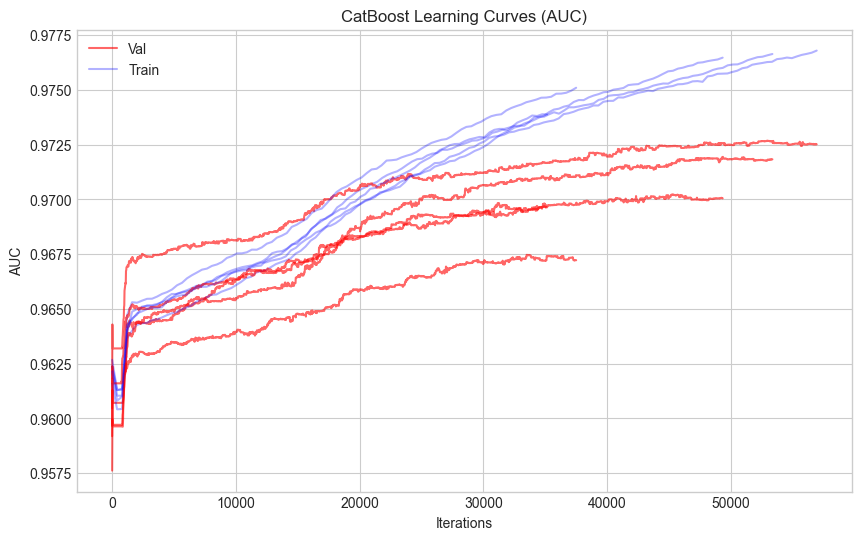

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='auc', metric_period=metric_period)

### Feature Importance
Average feature importance across folds. This is a sanity check (not a causal explanation).

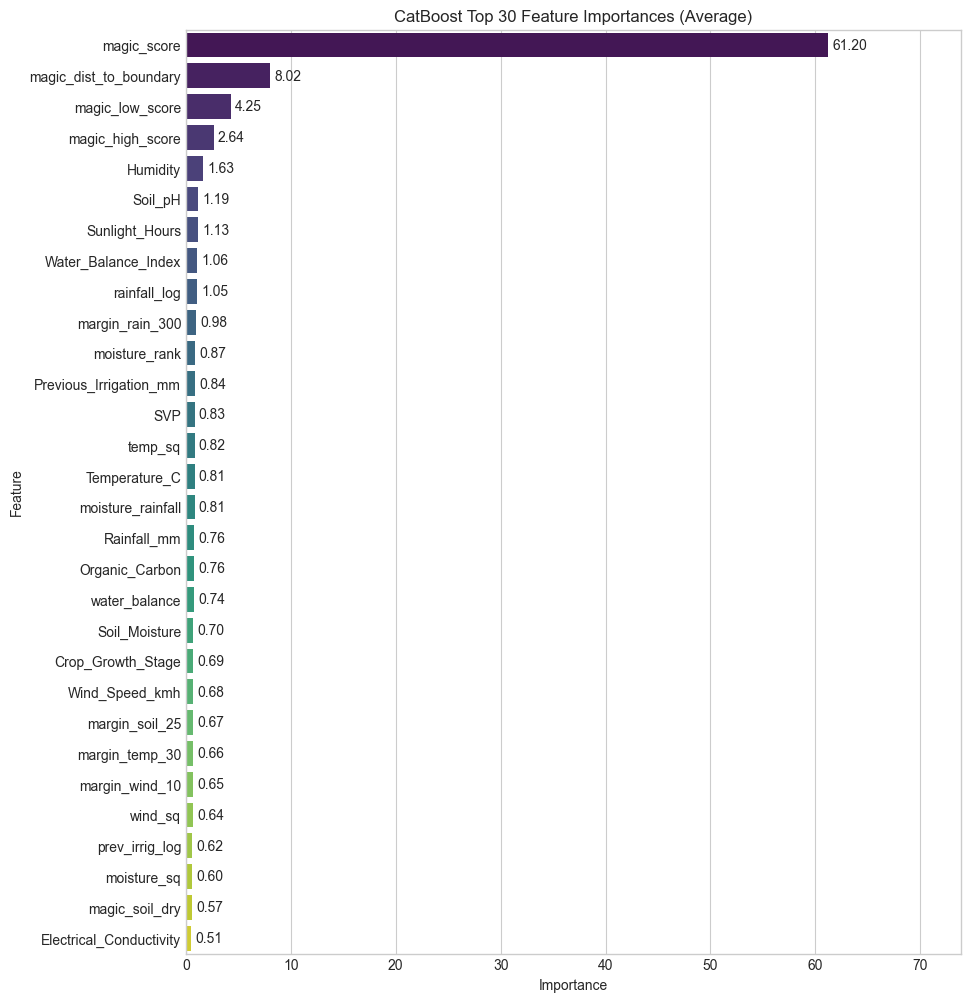

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Check if the model is over-predicting a specific irrigation level.  `y` is the actual ground truth, `oof_preds` is the argmax predictions.

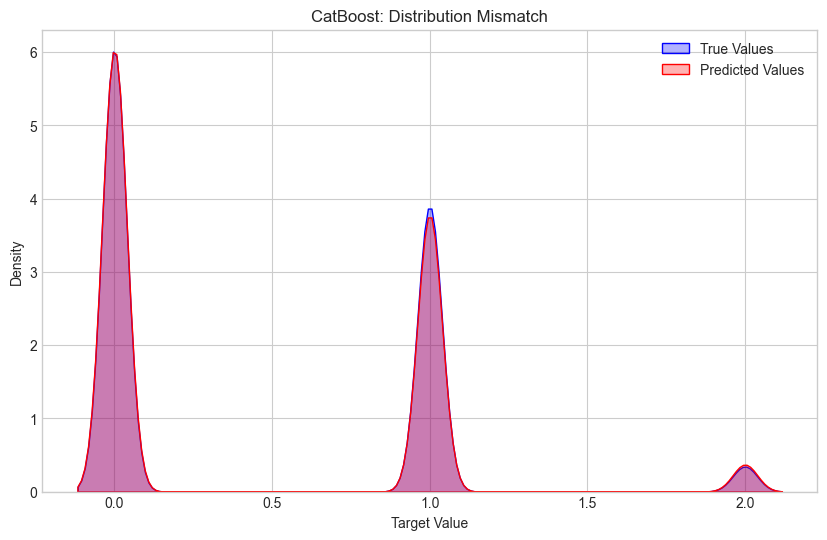

In [14]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### ROC Curves (One-vs-Rest)
The ROC curve visualizes the trade-off between the True Positive Rate and False Positive Rate for each class. In this multi-class setting, we look for high AUC scores across all three irrigation levels.

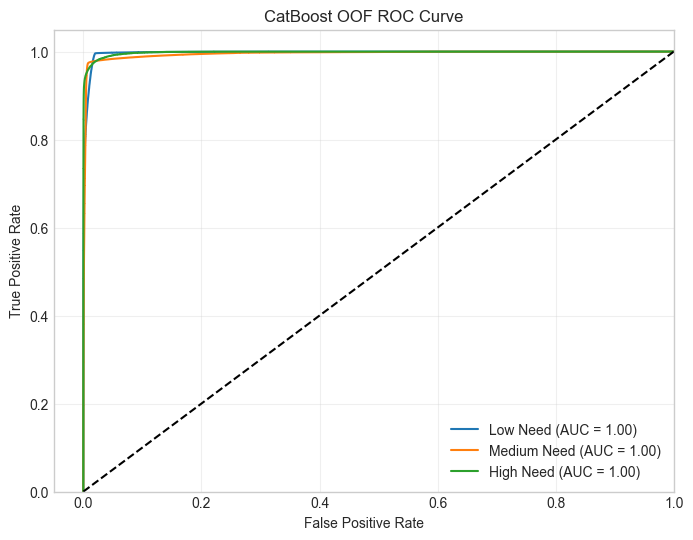

In [15]:
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs, title='CatBoost OOF ROC Curve')

### Confusion Matrix (Out-of-Fold)
The confusion matrix helps identify specific error modes by showing which classes the model frequently confuses. For example, it reveals if the model often predicts "Medium Irrigation" when the actual need is "High." Since this is a multi-class task, predictions are determined by selecting the class with the highest predicted probability (**Argmax**).

Normalized confusion matrix


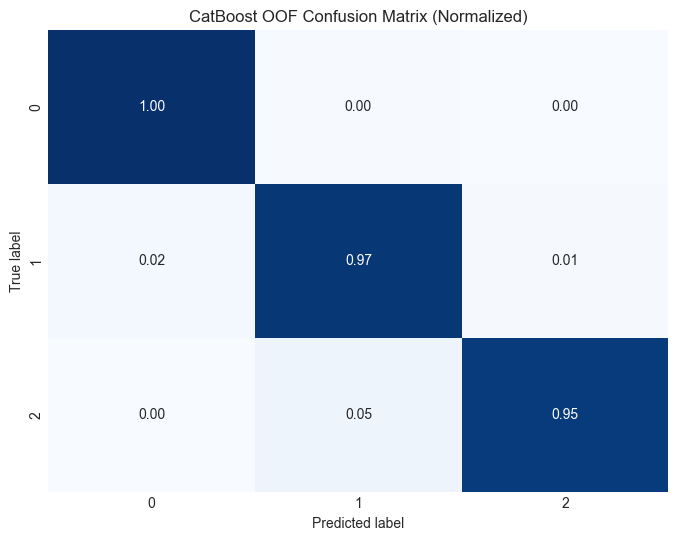

In [16]:
mviz.plot_confusion_matrix(y_true=y, y_pred=oof_preds, classes=[0,1,2], normalize=True, title='CatBoost OOF Confusion Matrix (Normalized)')

## Prepare Submission

We generate the final submission file according to the competition's schema. Since the evaluation metric is Balanced Accuracy, the submission requires the hard predicted class for each crop:

- **0**: Low Irrigation Need
- **1**: Medium Irrigation Need
- **2**: High Irrigation Need

The predictions are derived by selecting the class with the highest predicted probability (**Argmax**) for each sample in the test set.

In [17]:
submission_df = helper.read_dataset('submission')

target_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
numeric_preds = np.argmax(test_probs, axis=1)

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [18]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).
  
For this multi-class task, we save the full probability distribution (the confidence scores for categories 0, 1, and 2) rather than just the final predicted labels. Saving the raw probabilities is essential for:

- **Weighted Blending**: Combining multiple models by averaging their confidence scores.
- **Stacking**: Using these probabilities as "meta-features" for a secondary model.
- **Calibration Analysis**: Evaluating how well the model's confidence aligns with actual agricultural outcomes.


In [19]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Define column names for the probabilities
prob_cols = ['prob_low', 'prob_medium', 'prob_high']

# Save OOF probabilities
# Create a DF for the probabilities first
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)

# Combine with ID and Target
oof_df = pd.concat([
    pd.DataFrame({
        'id': training_df['id'].values,
        'target': y.values
    }),
    oof_prob_df
], axis=1)

oof_df.to_csv(f'{output_dir}/catboost_oof_probs.csv', index=False)

# Save Test probabilities
test_prob_values_df = pd.DataFrame(test_probs, columns=prob_cols)

test_prob_df = pd.concat([
    pd.DataFrame({
        'id': test_df['id'].values
    }),
    test_prob_values_df
], axis=1)
test_prob_df.to_csv(f'{output_dir}/catboost_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/catboost_oof_probs.csv\n - {output_dir}/catboost_test_probs.csv')

Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
